# QA — Reconciliation Metabase vs Adjust (CDS Android)

Notebook orchestration: gọi `clients/` để lấy data, gọi `reconciliation/` để xử lý.
Toàn bộ logic thật nằm trong 2 package đó — sửa logic ở đó, không sửa ở đây.

Đối chiếu đủ 12 chỉ số: ROAS D0-D28, Revenue D0-D28, Cost, Installs — sai số tương đối
thống nhất `ratio = mb/adj`, ngưỡng `config.THRESHOLD_PCT`. Cohort chưa đủ maturity theo
`Cohort Age` bị loại khỏi so sánh tự động.

In [2]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("..")

import config
import run_config as rc
from clients.adjust_client import AdjustClient
from clients.metabase_client import MetabaseClient
from reconciliation.normalize import normalize_metabase, normalize_adjust, filter_excluded_dates
from reconciliation.merge import merge_sources, report_join_gaps
from reconciliation.flags import build_detail
from reconciliation.summary import summarize, top_discrepancy
from reconciliation import eda

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 0. (Tuỳ chọn) Override config riêng cho lần chạy này

`config.EXCLUDED_DATES` và `config.DATA_ASOF_DATE` là kiến thức riêng theo từng lần chạy
(ngày nào bị lỗi, chốt dữ liệu vào lúc nào) — override trực tiếp ở đây thay vì sửa `config.py`
nếu chỉ dùng cho 1 lần đối chiếu cụ thể.

In [3]:
game = config.GAMES[rc.GAME_KEY]
adjust_app_token = config.get_adjust_app_token(rc.GAME_KEY)
adjust_extra_params = config.get_adjust_extra_params(rc.GAME_KEY, rc.NETWORK_KEY)   # <-- đổi từ game["adjust_extra_params"]
metabase_network_value = config.get_metabase_network_value(rc.NETWORK_KEY)          # <-- LIST giá trị Metabase (network giờ là Field Filter multi-select)

config.EXCLUDED_DATES = rc.EXCLUDED_DATES
config.DATA_ASOF_DATE = rc.DATA_ASOF_DATE

# [CẬP NHẬT 2026-09-26] Card Metabase id=81 đã bỏ date_from/date_to, thay bằng
# Field Filter "cohort_date" (type date/all-options) — dùng chung 1 khoảng ngày,
# format START~END (Metabase) khớp adjust_date_period format START:END (Adjust).
metabase_date_range = f"{rc.DATE_PERIOD_START}~{rc.DATE_PERIOD_END}"
adjust_date_period = f"{rc.DATE_PERIOD_START}:{rc.DATE_PERIOD_END}"

print(f"Đang chạy cho: {game['label']} — network: {rc.NETWORK_KEY}")
print(f"Khoảng ngày: {rc.DATE_PERIOD_START} -> {rc.DATE_PERIOD_END}")

Đang chạy cho: Game C (BCE) — iOS — network: ['applovin', 'unity']
Khoảng ngày: 2026-08-05 -> 2026-09-25


## 1. Lấy dữ liệu Metabase

In [4]:
mb = MetabaseClient(base_url=config.METABASE_URL, api_key=config.METABASE_API_KEY)

# [CẬP NHẬT 2026-09-26] Card id=81 sửa lại phía owner (2026-09-24): "network",
# "game", "platform" giờ là Field Filter multi-select thật (không còn Plain
# Variable scalar) — PHẢI truyền value dạng LIST dù chỉ chọn 1 giá trị, nếu
# không Organic/game khác có thể lọt vào (đã xác nhận qua request thật tới
# API, xem ghi chú trong config.py cạnh NETWORK_OPTIONS).
parameters = mb.build_parameters(
    game["metabase_card_id"],
    cohort_date=metabase_date_range,       # "2026-08-01~2026-09-17" — Field Filter date/all-options
    network=metabase_network_value,        # list, VD ["APPLOVIN"] hoặc ["APPLOVIN","UNITY"]
    game=[game["metabase_game"]],          # list, VD ["Game C"] — không còn scalar
    platform=[game["metabase_platform"]],  # list, VD ["IOS"] — không còn scalar
)

df_mb = mb.query_card(game["metabase_card_id"], parameters)
print("Số dòng Metabase:", df_mb.shape[0])
df_mb.head()

Số dòng Metabase: 129


,Cohort Date,Game,Platform,Network,Campaign,Cost,Adjust Installs,Installs,CPI,Bid,...,Revenue Complete Through,Beta D1,Beta D3,Beta D7,Beta D14,Beta D28,Beta D30,BE Day,ROAS BEDay,BE Status
0,2026-09-25T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,6247.858793,668,668,9.3531,0.452971,...,2026-09-25T00:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
1,2026-09-25T00:00:00Z,Game C,IOS,UNITY,BCE iOS - D28 BLDROAS - 260701,1430.588454,548,549,2.6058,NaN,...,2026-09-25T00:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,None,None,None
2,2026-09-24T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,7261.002415,902,902,8.0499,0.453734,...,2026-09-25T00:00:00Z,1.502137,NaN,NaN,NaN,NaN,NaN,None,None,None
3,2026-09-24T00:00:00Z,Game C,IOS,UNITY,BCE iOS - D28 BLDROAS - 260701,1476.750379,605,605,2.4409,NaN,...,2026-09-25T00:00:00Z,1.612659,NaN,NaN,NaN,NaN,NaN,None,None,None
4,2026-09-23T00:00:00Z,Game C,IOS,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,6030.687344,1020,1021,5.9066,0.452189,...,2026-09-25T00:00:00Z,1.534377,NaN,NaN,NaN,NaN,NaN,None,None,None


## 2. Lấy dữ liệu Adjust
Dùng `config.ADJUST_METRICS_CDS_ANDROID` — đã gồm đủ Installs, Cost, ROAS D0-D28, Revenue D0-D28.

In [5]:
adjust = AdjustClient(api_token=config.ADJUST_API_TOKEN)

df_adjust, adjust_totals = adjust.fetch_report(
    app_token=adjust_app_token,
    dimensions=["day", "network", "campaign_network"],
    metrics=config.get_adjust_metrics(rc.GAME_KEY),
    date_period=adjust_date_period,
    extra_params=adjust_extra_params,   # <-- đổi từ game["adjust_extra_params"]
)

print("Số dòng Adjust:", df_adjust.shape[0])
print("Totals:", adjust_totals)
df_adjust.head()

Số dòng Adjust: 129
Totals: {'installs': 128681.0, 'network_cost': 532063.6413, 'roas_cal_d0': 0.0968, 'roas_cal_d3': 0.2056, 'roas_cal_d7': 0.2747, 'roas_cal_d14': 0.346, 'roas_cal_d28': 0.4324, 'ad_revenue_total_cal_d0': 49974.946, 'ad_revenue_total_cal_d3': 101438.6868, 'ad_revenue_total_cal_d7': 123122.1853, 'ad_revenue_total_cal_d14': 129459.452, 'ad_revenue_total_cal_d28': 87699.2606, 'revenue_total_cal_d0': 1551.481, 'revenue_total_cal_d3': 6365.834, 'revenue_total_cal_d7': 11205.282, 'revenue_total_cal_d14': 15327.863, 'revenue_total_cal_d28': 15128.804}


,day,network,campaign_network,installs,network_cost,roas_cal_d0,roas_cal_d3,roas_cal_d7,roas_cal_d14,roas_cal_d28,ad_revenue_total_cal_d0,ad_revenue_total_cal_d3,ad_revenue_total_cal_d7,ad_revenue_total_cal_d14,ad_revenue_total_cal_d28,revenue_total_cal_d0,revenue_total_cal_d3,revenue_total_cal_d7,revenue_total_cal_d14,revenue_total_cal_d28
0,2026-09-01,Unity,BCE iOS - D28 BLDROAS - 260701,4782,8614.6871,0.0882,0.2016,0.2646,0.3383,0.0,754.9953,1661.0499,2186.9973,2792.6797,0.0,4.794,75.461,92.567,121.522,0.0
1,2026-08-30,Unity,BCE iOS - D28 BLDROAS - 260701,4456,9206.5478,0.0919,0.1756,0.2412,0.3224,0.4077,842.4562,1608.569,2185.4229,2850.9978,3471.1652,3.909,7.894,35.246,117.228,282.147
2,2026-08-27,Unity,BCE iOS - D28 BLDROAS - 260701,4056,8607.4785,0.0928,0.1886,0.2492,0.3146,0.3978,791.4412,1571.9885,2057.5364,2537.3719,3141.2918,7.016,51.696,87.477,170.964,282.965
3,2026-08-31,Unity,BCE iOS - D28 BLDROAS - 260701,4051,8282.2249,0.0951,0.1862,0.2457,0.314,0.0,776.7082,1516.5763,1964.4906,2483.7238,0.0,10.625,25.772,70.656,117.289,0.0
4,2026-09-04,Unity,BCE iOS - D28 BLDROAS - 260701,3905,7196.7793,0.0963,0.2029,0.2557,0.3057,0.0,690.1859,1442.0712,1816.0542,2160.5356,0.0,2.742,18.448,24.448,39.294,0.0


## 3. Normalize + loại ngày lỗi + Merge

In [6]:
mb_norm = normalize_metabase(df_mb)
adj_norm = normalize_adjust(df_adjust)

mb_norm = filter_excluded_dates(mb_norm, config.EXCLUDED_DATES)
adj_norm = filter_excluded_dates(adj_norm, config.EXCLUDED_DATES)

merged = merge_sources(mb_norm, adj_norm)
join_stats = report_join_gaps(merged)


Khớp cả 2 nguồn: 129 dòng
Chỉ có ở Metabase: 0 dòng
Chỉ có ở Adjust: 0 dòng


## 4. Tính bảng đối chiếu chi tiết (long-format)
Mỗi dòng = 1 cohort x 1 metric. Dùng `merged` đầy đủ (kể cả phần lệch join key) —
các dòng đó tự ra flag "N/A (thiếu dữ liệu)", không bị âm thầm bỏ qua.

In [7]:
metric_map = config.get_metric_map(rc.GAME_KEY)
detail = build_detail(merged, metric_map)
detail.head(10)

Cohort Age tính theo DATA_ASOF_DATE = 2026-09-24
EXCLUDE_IMMATURE_COHORTS = True
[CHỐT] Sai số tương đối ratio = mb/adj. Ngưỡng Discrepancy: |rel_diff_pct| > 5.0%

Bảng detail: 2193 dòng (= 129 cohort x 17 chỉ số)
Số dòng bị loại vì cohort chưa đủ maturity: 348


,cohort_date,network,campaign,metric,cohort_age_days,is_immature,mb_value,adjust_value,abs_diff,ratio,rel_diff_pct,flag
0,2026-08-05,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D0,50,False,381.425349,384.9637,-3.538351,0.990809,-0.9191,OK
1,2026-08-05,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D0,50,False,44.954394,44.9568,-0.002406,0.999946,-0.0054,OK
2,2026-08-05,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D0,50,False,6.676772,6.6768,-0.000028,0.999996,-0.0004,OK
3,2026-08-05,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D14,50,False,1229.955927,1243.6689,-13.712973,0.988974,-1.1026,OK
4,2026-08-05,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D14,50,False,182.008821,182.1561,-0.147279,0.999191,-0.0809,OK
5,2026-08-05,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,50,False,7.538568,7.5386,-0.000032,0.999996,-0.0004,OK
6,2026-08-05,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D28,50,False,1487.052963,1500.4200,-13.367037,0.991091,-0.8909,OK
7,2026-08-05,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D28,50,False,224.397514,224.4927,-0.095186,0.999576,-0.0424,OK
8,2026-08-05,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,50,False,7.538568,7.5386,-0.000032,0.999996,-0.0004,OK
9,2026-08-05,APPLOVIN,BCE iOS - D28 BLDROAS - Main tier - 260506,AD_REVENUE_D3,50,False,714.225888,718.8084,-4.582512,0.993625,-0.6375,OK


## 5. Tổng hợp % Discrepancy — theo Campaign x Metric, và toàn hệ thống

In [8]:
summary_result = summarize(detail)
summary_by_campaign = summary_result["by_campaign"]
summary_overall = summary_result["overall"]


=== Tổng hợp theo từng Campaign ===
                                  campaign          metric  n_valid  mean_abs_diff  mean_ratio  mean_abs_rel_diff_pct  median_abs_rel_diff_pct  p90_abs_rel_diff_pct  pct_discrepancy
            BCE iOS - D28 BLDROAS - 260701         ROAS_D0       51         0.0001      0.9993                 0.0910                   0.0310                0.1097           0.0000
            BCE iOS - D28 BLDROAS - 260701         ROAS_D3       48         0.0008      0.9964                 0.3586                   0.0955                1.0084           0.0000
            BCE iOS - D28 BLDROAS - 260701         ROAS_D7       44         0.0017      0.9940                 0.6049                   0.3087                1.4077           2.2727
            BCE iOS - D28 BLDROAS - 260701        ROAS_D14       37         0.0030      0.9912                 0.8871                   0.6362                1.9617           2.7027
            BCE iOS - D28 BLDROAS - 260701        ROAS

In [9]:
print([c for c in merged.columns if "ad_revenue" in c or "revenue_total" in c])

['ad_revenue_total_cal_d0_mb', 'ad_revenue_total_cal_d1', 'ad_revenue_total_cal_d3_mb', 'ad_revenue_total_cal_d7_mb', 'ad_revenue_total_cal_d14_mb', 'ad_revenue_total_cal_d28_mb', 'ad_revenue_total_cal_d30', 'revenue_total_cal_d0_mb', 'revenue_total_cal_d1', 'revenue_total_cal_d3_mb', 'revenue_total_cal_d7_mb', 'revenue_total_cal_d14_mb', 'revenue_total_cal_d28_mb', 'revenue_total_cal_d30', 'ad_revenue_total_cal_d0_adj', 'ad_revenue_total_cal_d3_adj', 'ad_revenue_total_cal_d7_adj', 'ad_revenue_total_cal_d14_adj', 'ad_revenue_total_cal_d28_adj', 'revenue_total_cal_d0_adj', 'revenue_total_cal_d3_adj', 'revenue_total_cal_d7_adj', 'revenue_total_cal_d14_adj', 'revenue_total_cal_d28_adj']


## 6. Top các dòng lệch nhiều nhất — ưu tiên kiểm tra trước

In [10]:
top = top_discrepancy(detail, top_n=20, per_campaign=5)

print("=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===")
display(top["top_overall"])

print("\n=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===")
display(top["top_per_campaign"])


=== Top 20 lệch nhiều nhất (toàn bộ campaign) ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
212,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,40.746199,93.6968,-52.950601,-56.5127
248,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.304818,0.7009,-0.396082,-56.5105
245,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D14,0.284827,0.5825,-0.297673,-51.1026
209,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,38.073937,77.8599,-39.785963,-51.0994
218,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,36.164558,72.4304,-36.265842,-50.0699
254,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D7,0.270543,0.5418,-0.271257,-50.0658
263,2026-08-10,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,14.005017,26.9097,-12.904683,-47.9555
299,2026-08-10,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.194970,0.3746,-0.179630,-47.9525
167,2026-08-08,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,19.763404,32.9102,-13.146796,-39.9475
203,2026-08-08,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D7,0.343929,0.5727,-0.228771,-39.9460



=== Top 5 lệch nhiều nhất THEO TỪNG CAMPAIGN ===


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct
313,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D28,351.855725,377.9174,-26.061675,-6.8961
349,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,ROAS_D28,0.543138,0.5811,-0.037962,-6.5328
319,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D7,211.221125,223.9067,-12.685575,-5.6656
310,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D14,302.626048,320.0596,-17.433552,-5.4470
316,2026-08-11,UNITY,BCE iOS - D28 BLDROAS - 260701,AD_REVENUE_D3,166.763282,176.0663,-9.303018,-5.2838
212,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D28,40.746199,93.6968,-52.950601,-56.5127
248,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D28,0.304818,0.7009,-0.396082,-56.5105
245,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,ROAS_D14,0.284827,0.5825,-0.297673,-51.1026
209,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D14,38.073937,77.8599,-39.785963,-51.0994
218,2026-08-09,UNITY,BCE iOS - D7 BLDROAS - 260701,AD_REVENUE_D7,36.164558,72.4304,-36.265842,-50.0699


## 7. (Tuỳ chọn) Xuất kết quả
Thêm cell ghi `detail`/`summary_by_campaign`/`summary_overall` ra BigQuery / Google Sheets /
`.docx` report tại đây, khi bạn đã sẵn sàng nối vào pipeline output hiện có.

```python
# detail.to_csv("../outputs/reconciliation_detail.csv", index=False, encoding="utf-8-sig")
# summary_by_campaign.to_csv("../outputs/reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
# summary_overall.to_csv("../outputs/reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")
```

In [11]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

detail.to_csv(output_dir / "reconciliation_detail.csv", index=False, encoding="utf-8-sig")
summary_by_campaign.to_csv(output_dir / "reconciliation_summary_by_campaign.csv", index=False, encoding="utf-8-sig")
summary_overall.to_csv(output_dir / "reconciliation_summary_overall.csv", index=False, encoding="utf-8-sig")

df_mb.to_csv(output_dir / "mb.csv", index=False, encoding="utf-8-sig")
df_adjust.to_csv(output_dir / "adj.csv", index=False, encoding="utf-8-sig")

print(f"Đã xuất kết quả vào: {output_dir.resolve()}")

Đã xuất kết quả vào: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_ios


## 8. EDA — Phân tích trực quan

### 8.1. So sánh Tổng — Metabase vs Adjust
Tổng Cost/Installs/Revenue D0-D28 cộng dồn trên toàn bộ khoảng ngày đã chọn. Không gồm ROAS
(là tỷ lệ, cộng dồn không có ý nghĩa) — xem xu hướng ROAS ở mục 8.5.

=== So sánh TỔNG (cộng dồn toàn bộ khoảng ngày) ===
           metric      mb_total  adjust_total   n  rel_diff_pct
    AD_REVENUE_D0  49193.831964    49218.9166 127 -5.096544e-02
    AD_REVENUE_D3  96645.123876    97003.8995 121 -3.698569e-01
    AD_REVENUE_D7 113654.742215   114401.3543 113 -6.526252e-01
   AD_REVENUE_D14 117830.901486   118943.0140  99 -9.349961e-01
   AD_REVENUE_D28  67495.206217    68257.5073  69 -1.116802e+00
   IAP_REVENUE_D0   1540.111000     1540.1110  92  0.000000e+00
   IAP_REVENUE_D3   6103.821000     6103.8210  97  0.000000e+00
   IAP_REVENUE_D7  10325.560000    10325.5600  95  0.000000e+00
  IAP_REVENUE_D14  13708.902000    13708.9020  82  0.000000e+00
  IAP_REVENUE_D28  12274.860000    12274.8600  54  0.000000e+00
             COST 532063.643030   532063.6413 129  3.251491e-07
         INSTALLS 128547.000000   128681.0000 129 -1.041335e-01
 TOTAL_REVENUE_D0  47444.146235    47463.2328  92 -4.021337e-02
 TOTAL_REVENUE_D3  99758.777590   100084.1167  97 -3

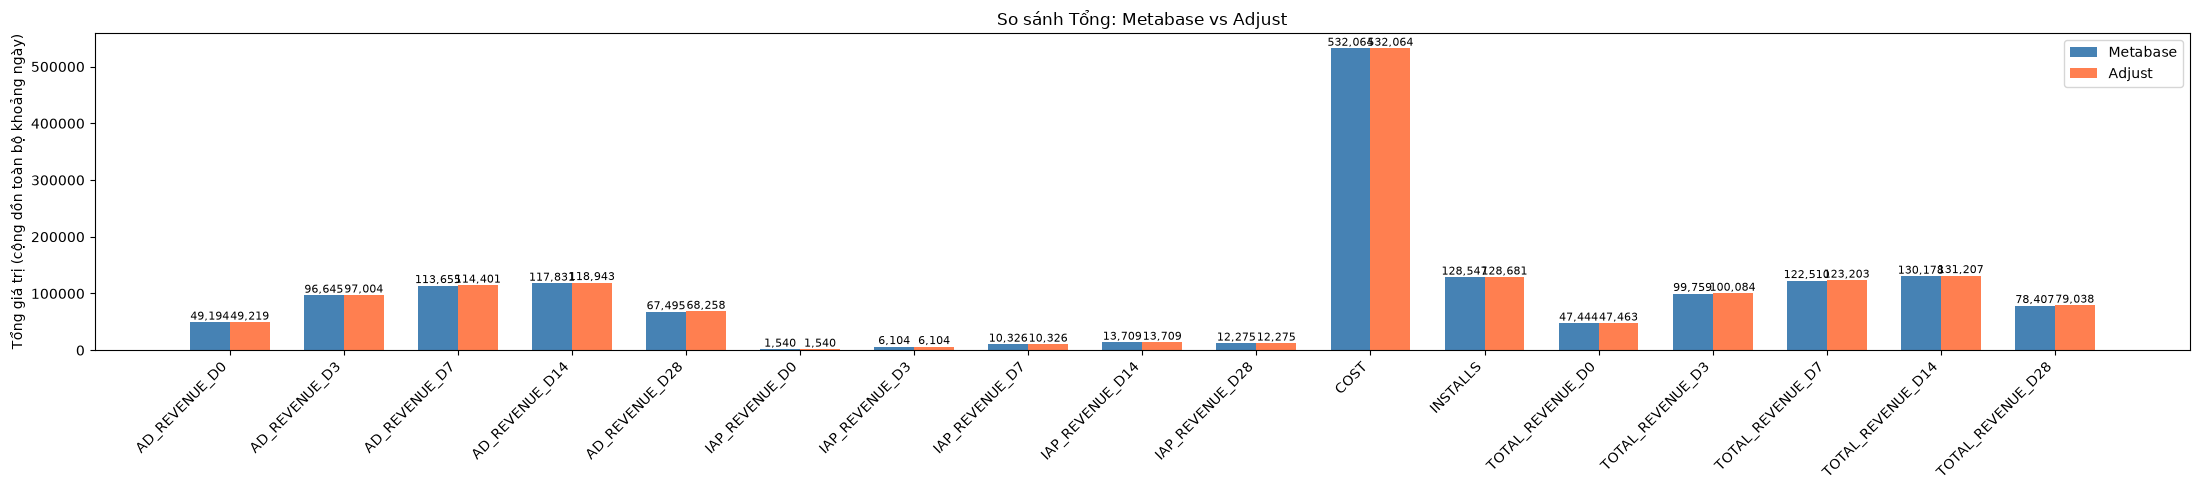

Đã lưu: D:\Document-D\2025.2\LabDATA\Game\QA\qa-pipeline\outputs\game_c_ios\reconciliation_totals_comparison.csv


In [12]:
from pathlib import Path

output_dir = Path("../outputs") / rc.GAME_KEY
output_dir.mkdir(parents=True, exist_ok=True)

totals = eda.compare_totals(detail)
eda.plot_totals_comparison(totals)


print(f"Đã lưu: {(output_dir / 'reconciliation_totals_comparison.csv').resolve()}")

In [13]:
import reconciliation.eda as eda
print(eda.SUMMABLE_METRICS)

['COST', 'INSTALLS', 'AD_REVENUE_D0', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'IAP_REVENUE_D0', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28']


In [14]:
print(sorted(detail["metric"].unique()))

['AD_REVENUE_D0', 'AD_REVENUE_D14', 'AD_REVENUE_D28', 'AD_REVENUE_D3', 'AD_REVENUE_D7', 'COST', 'IAP_REVENUE_D0', 'IAP_REVENUE_D14', 'IAP_REVENUE_D28', 'IAP_REVENUE_D3', 'IAP_REVENUE_D7', 'INSTALLS', 'ROAS_D0', 'ROAS_D14', 'ROAS_D28', 'ROAS_D3', 'ROAS_D7']


### 8.2. Tổng quan Campaign
Số lượng Campaign đang đối chiếu, và số ngày (cohort) mỗi Campaign có dữ liệu — giúp phát hiện
nhanh Campaign nào có mẫu quá nhỏ, cần cẩn trọng khi đọc % Discrepancy.

Số lượng Campaign đang đối chiếu: 3
                                            n_days  first_date   last_date
campaign                                                                  
BCE iOS - D28 BLDROAS - 260701                  52  2026-08-05  2026-09-25
BCE iOS - D28 BLDROAS - Main tier - 260506      52  2026-08-05  2026-09-25
BCE iOS - D7 BLDROAS - 260701                   25  2026-08-05  2026-08-30


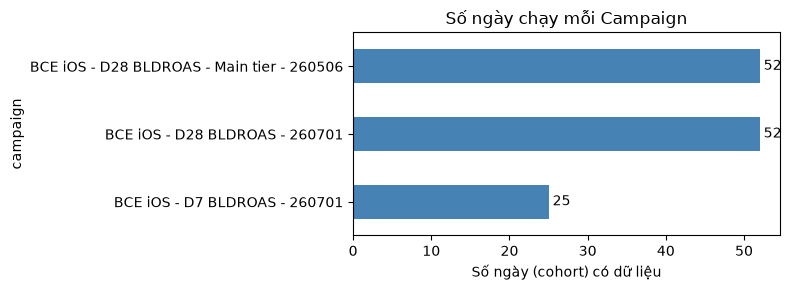

In [15]:
campaign_overview_df = eda.campaign_overview(detail)
eda.plot_campaign_overview(campaign_overview_df)

### 8.3. Heatmap % Discrepancy theo Campaign x Metric
Màu càng đỏ đậm, % Discrepancy càng cao — nhìn nhanh Campaign nào và Metric nào đang có vấn đề.

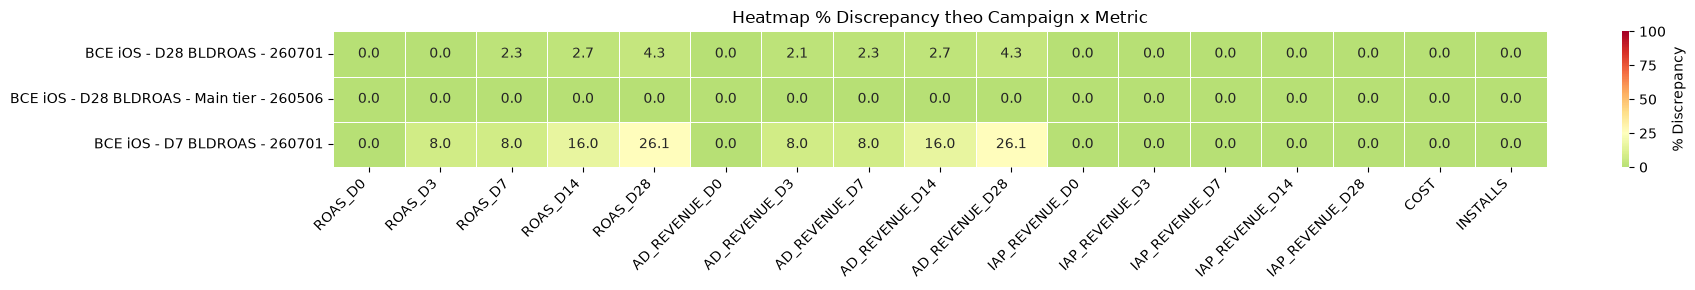

In [16]:
discrepancy_pivot = eda.plot_discrepancy_heatmap(summary_by_campaign)

### 8.4. Phân tích theo Metric — toàn hệ thống (gộp mọi Campaign)

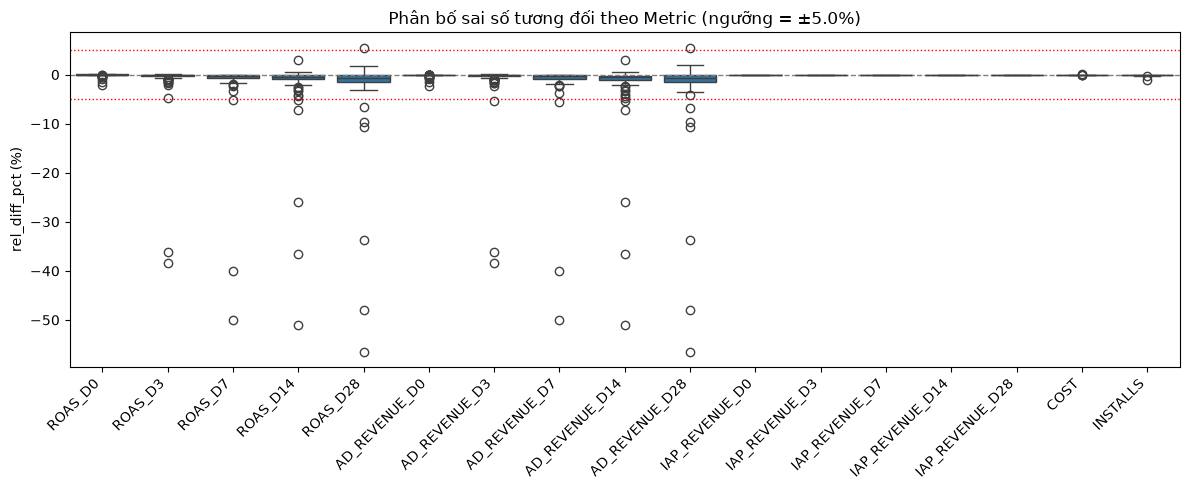

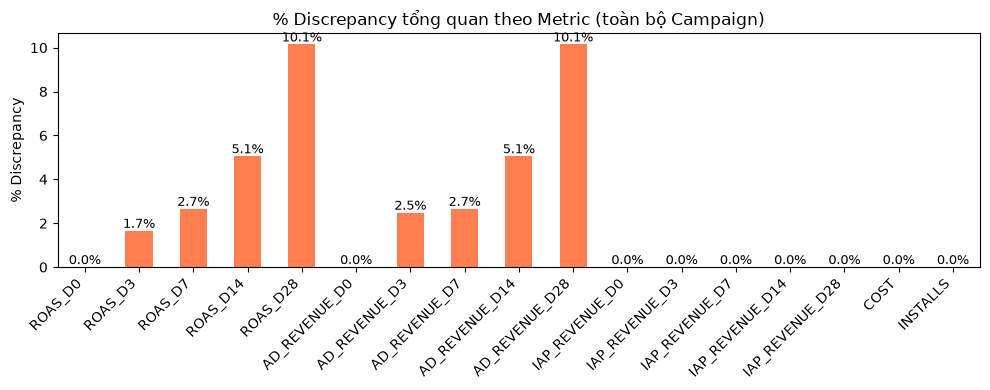

In [17]:
eda.plot_rel_diff_boxplot(detail)
eda.plot_overall_discrepancy_bar(summary_overall)

### 8.5. Xu hướng theo thời gian
- **Total**: trung bình `ratio = mb/adj` mỗi ngày, gộp tất cả campaign, cho vài metric đại diện.
- **Theo Campaign**: 1 đường/campaign, cho ĐÚNG 1 metric (đổi `metric=...` để xem chỉ số khác).

Đường `ratio = 1` (nét đứt) là khớp hoàn toàn.

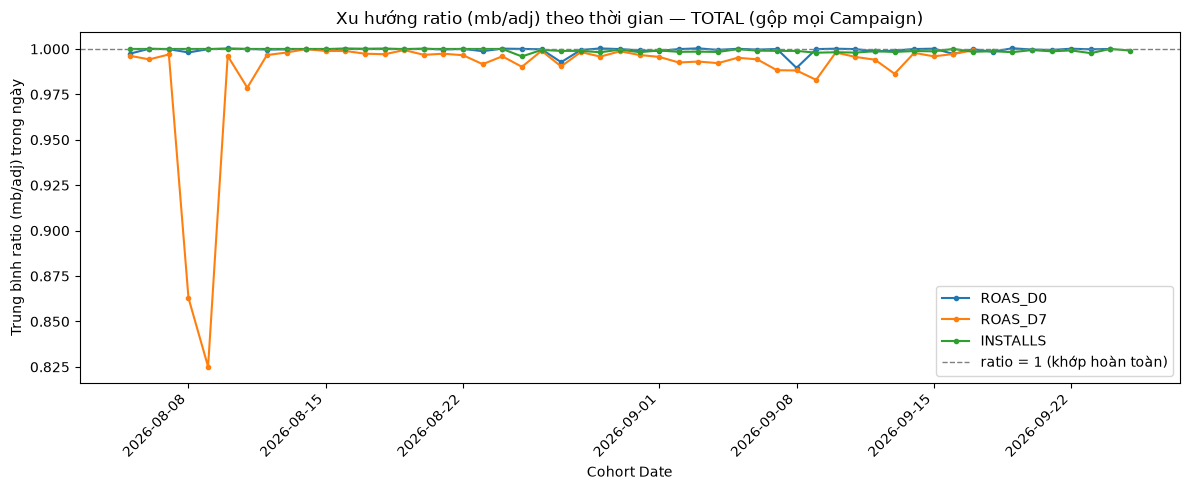

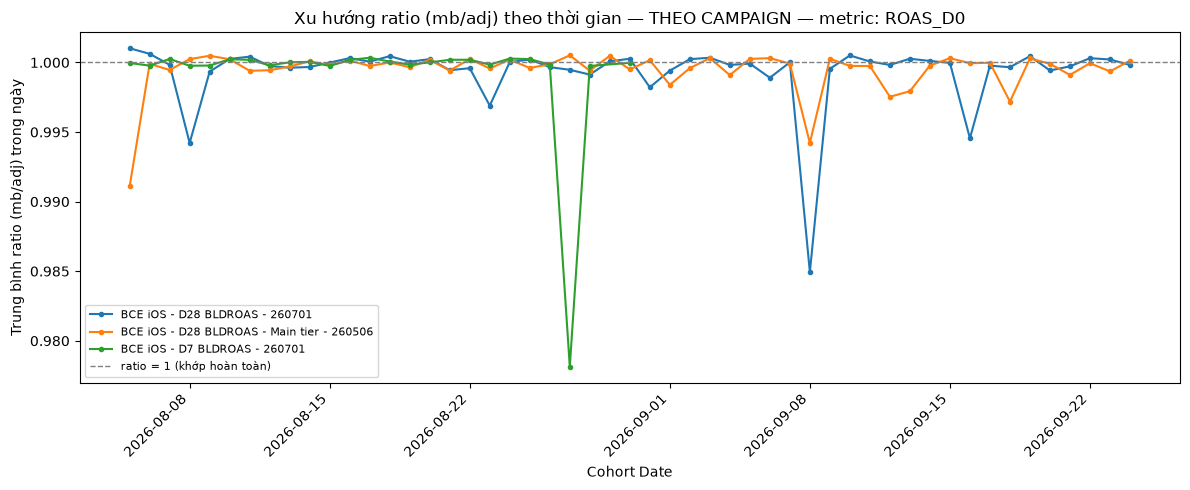

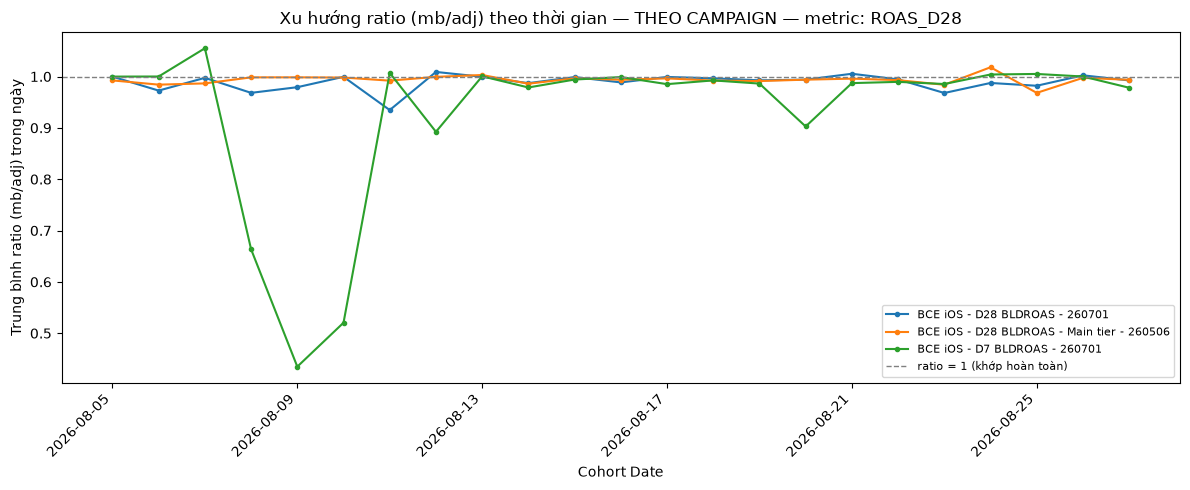

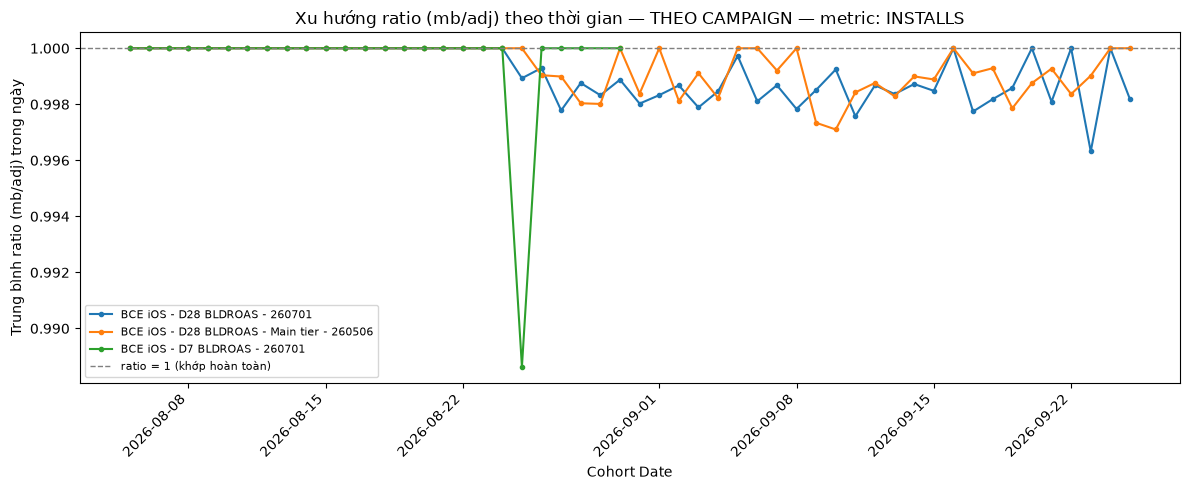

In [18]:
# Total — gộp mọi campaign
eda.plot_ratio_trend(detail, metrics=["ROAS_D0", "REVENUE_D0", "ROAS_D7", "REVENUE_D7", "INSTALLS"])

# Theo từng Campaign — đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D0")
eda.plot_ratio_trend_by_campaign(detail, metric="ROAS_D28")
eda.plot_ratio_trend_by_campaign(detail, metric="INSTALLS")

### 8.7. Phân bố sai số tương đối — Histogram & ECDF
- **Histogram (tất cả Campaign)**: 1 ô/metric, thấy hình dạng phân bố thật (lệch, đa đỉnh...).
- **Histogram theo Campaign**: 1 ô/campaign, cho 1 metric cụ thể — phát hiện campaign nào
  gây lệch phân bố chung.
- **ECDF**: trả lời trực tiếp "bao nhiêu % cohort đạt ngưỡng ±5%?" — đọc tại giao điểm với
  đường ngưỡng đỏ.

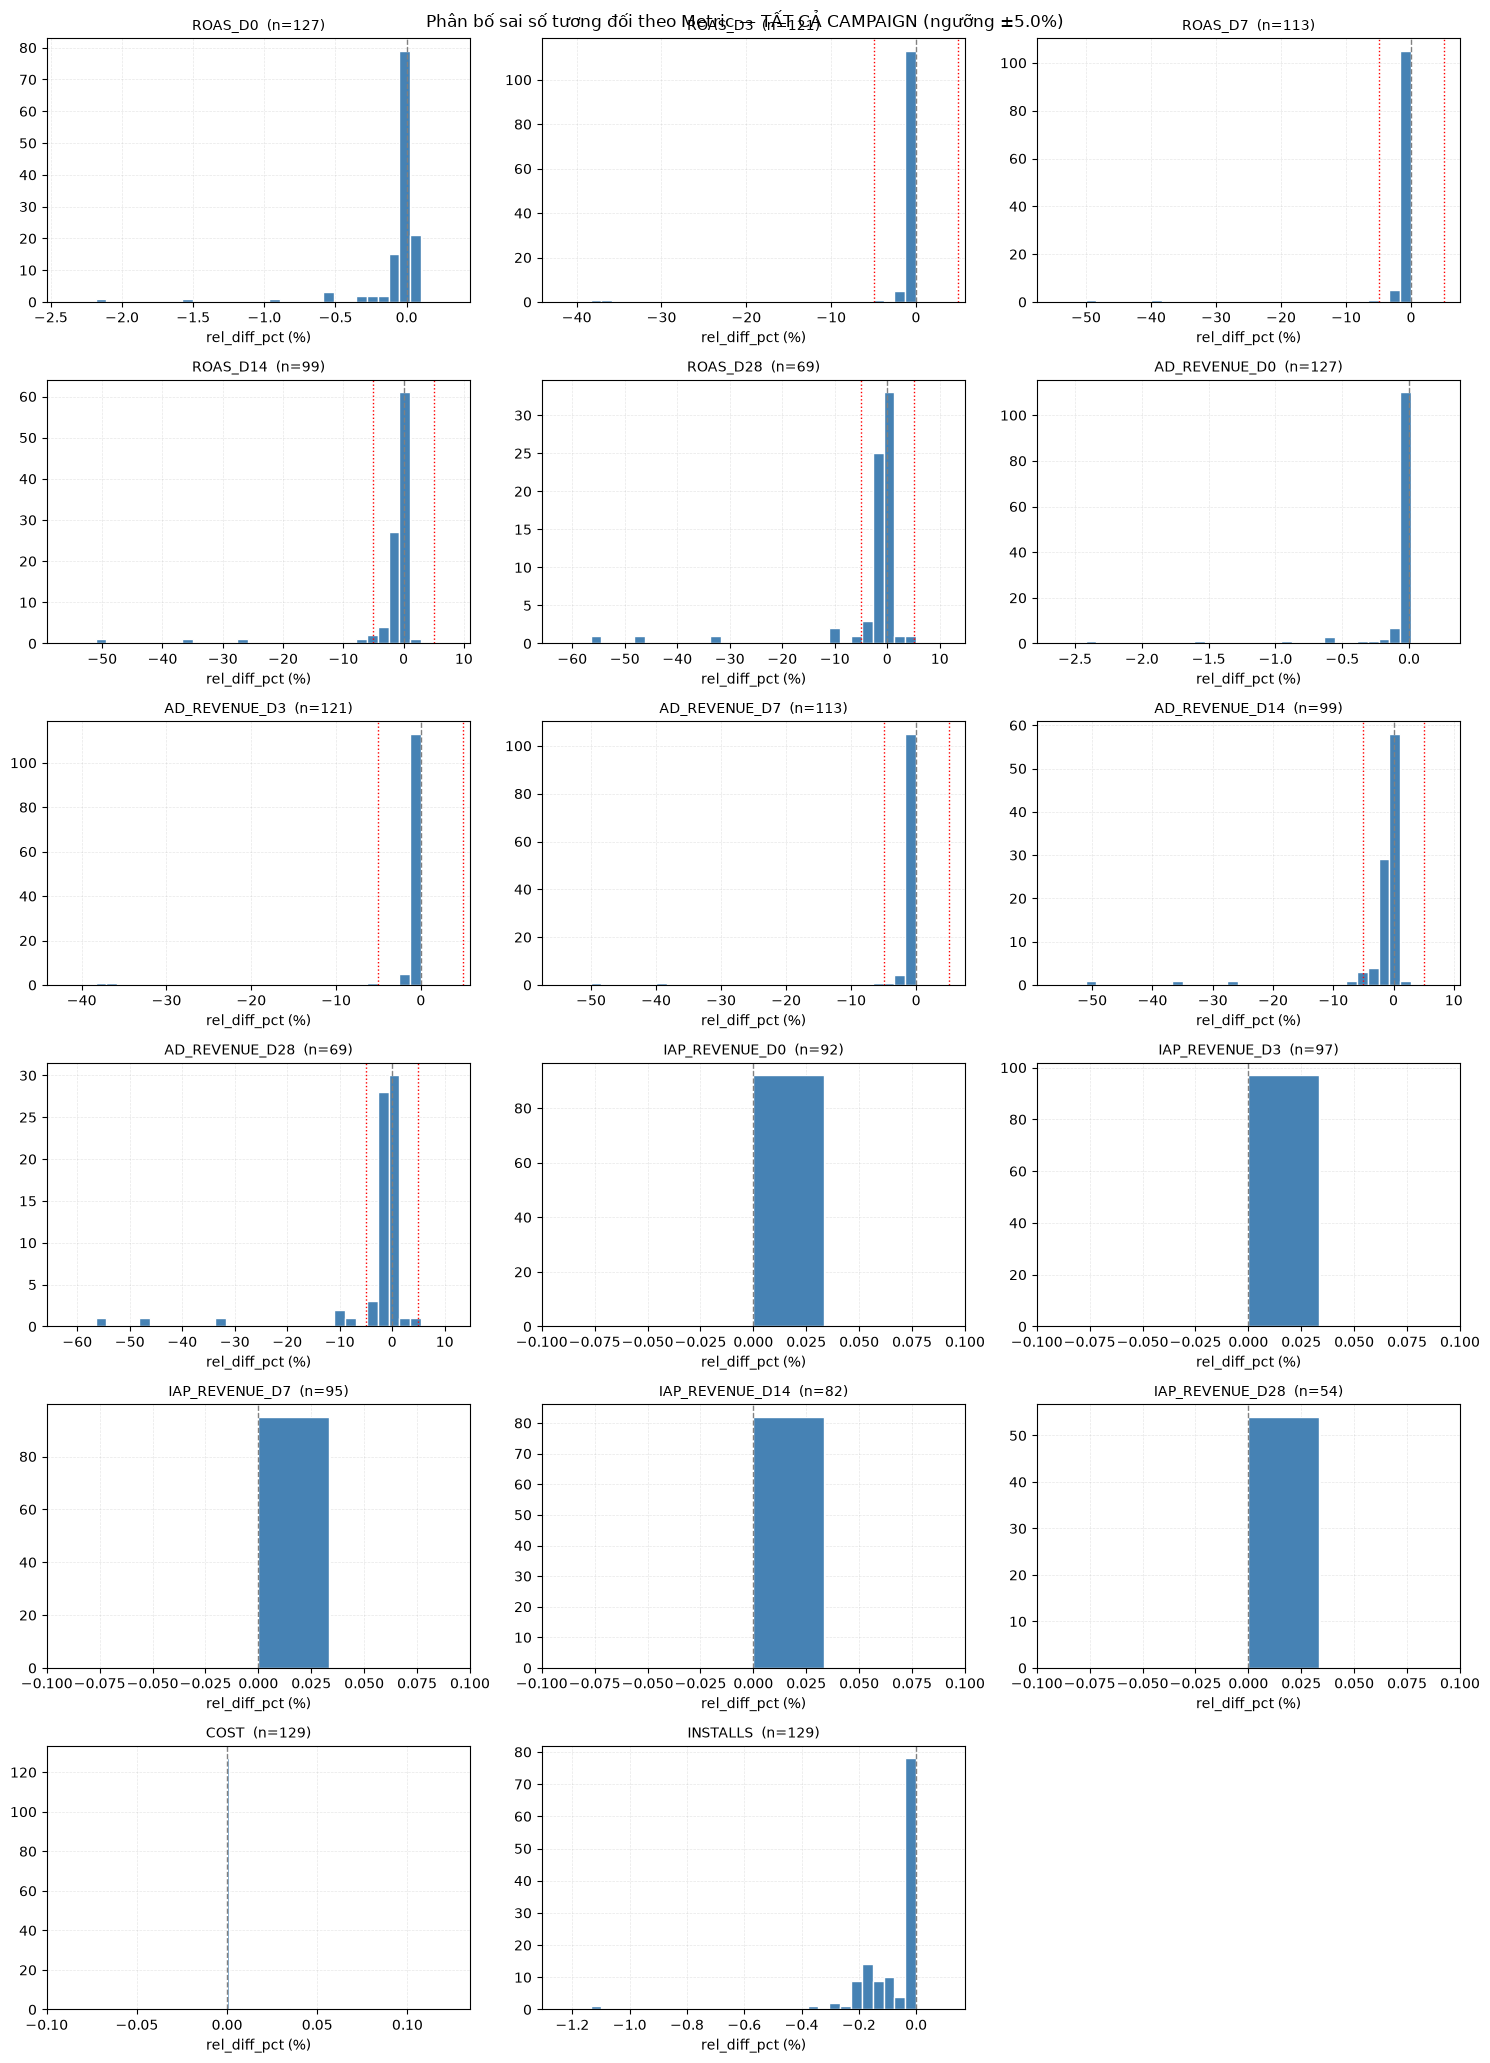

In [19]:
eda.plot_rel_diff_histogram(detail)

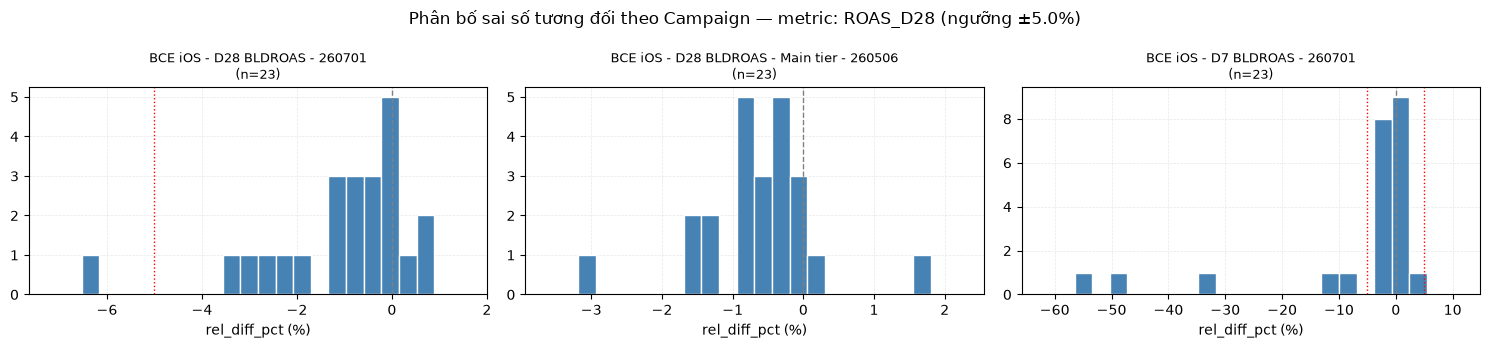

In [20]:
# Đổi metric để xem chỉ số khác (VD "COST", "REVENUE_D7"...)
eda.plot_rel_diff_histogram_by_campaign(detail, metric="ROAS_D28")

In [21]:
eda.plot_rel_diff_histogram_for_campaign(detail, campaign="BCE Android - D28 AdROAS - 260813")

⚠️ Không tìm thấy dữ liệu hợp lệ cho campaign 'BCE Android - D28 AdROAS - 260813'. Kiểm tra lại tên campaign (VD: sorted(detail['campaign'].unique())).


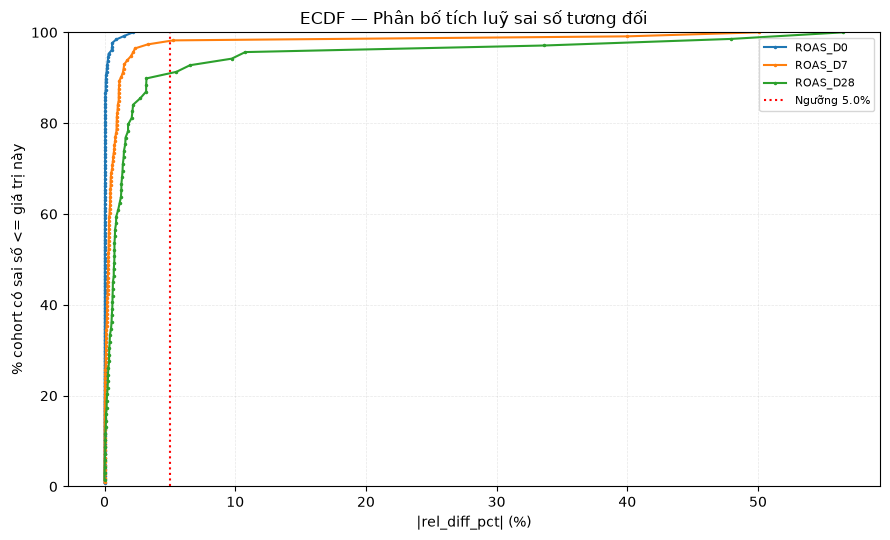

=== % cohort đạt ngưỡng (|rel_diff_pct| <= THRESHOLD_PCT) ===
  metric   n  pct_within_threshold
 ROAS_D0 127                 100.0
 ROAS_D7 113                  97.3
ROAS_D28  69                  89.9


In [22]:
pct_within_df = eda.plot_rel_diff_ecdf(detail, metrics=["ROAS_D0", "ROAS_D7", "ROAS_D28", "REVENUE_D0"])

In [23]:
from reconciliation.summary import iap_mismatches

iap_diff = iap_mismatches(detail)
print(f"{len(iap_diff)} dòng (cohort x metric) có IAP khác nhau")
iap_diff.to_csv(output_dir / "iap_mismatches.csv", index=False, encoding="utf-8-sig")
iap_diff


0 dòng (cohort x metric) có IAP khác nhau


,cohort_date,network,campaign,metric,mb_value,adjust_value,abs_diff,rel_diff_pct,flag
